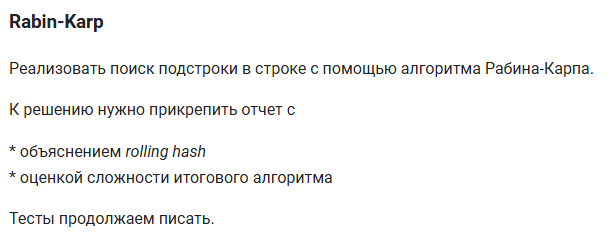
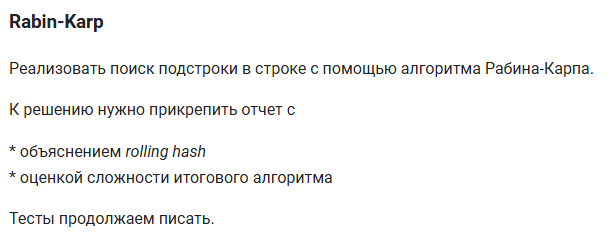

### Объяснение Rolling Hash

Алгоритм Рабина-Карпа ускоряет поиск подстроки за счет использования хеширования. Вместо того чтобы сравнивать саму подстроку с окном в тексте символ за символом, мы сравниваем их хеш-значения. Если хеши не совпадают, строки точно разные. Если совпадают — проверяем символы, так как возможна коллизия.

Чтобы не пересчитывать хеш для каждого нового окна с нуля, что занимало бы O(M), используется Rolling Hash. Это техника, позволяющая получить хеш следующего окна на основе хеша предыдущего за константное время O(1).

Обычно используется полиномиальный хеш:
$$H = (c_0 \cdot b^{k-1} + c_1 \cdot b^{k-2} + ... + c_{k-1} \cdot b^0) \mod q$$

Где:
* b - основание системы счисления, обычно размер алфавита, например 256.
* q - большое простое число (для минимизации коллизий).

Как работает "сдвиг" (Rolling):
Допустим, текущее окно — txt[i...i+m-1]. Мы хотим перейти к txt[i+1...i+m].
1. Удалить старый символ: Вычитаем значение первого символа текущего окна: $H_{temp} = H_{old} - txt[i] \cdot b^{m-1}$.
2. Сдвинуть разряды: Умножаем результат на $b$ (это аналогично сдвигу влево в десятичной системе): $H_{temp} = H_{temp} \cdot b$.
3. Добавить новый символ: Прибавляем значение нового символа, входящего в окно справа: $H_{new} = H_{temp} + txt[i+m]$.

Итоговая формула пересчета:
$$H_{new} = ((H_{old} - txt[i] \cdot h) \cdot b + txt[i+m]) \mod q$$
(где $h = b^{m-1} \mod q$ - предварительно вычисленный множитель старшего разряда).

### Оценка сложности

Обозначим: N - длина текста, M - длина паттерна (подстроки).

* Предварительная обработка: Вычисление хеша паттерна и первого окна текста занимает O(M).
* Средний и лучший случай: O(N + M).
    Мы проходим по тексту один раз. Пересчет хеша занимает O(1). Если коллизий (ложных совпадений хешей) мало, то алгоритм работает линейно.
* Худший случай: O(N*M).
    Происходит, если хеш-функция плохая или специально подобрана так, что хеши совпадают очень часто (много коллизий), но строки при этом разные. В этом случае на каждом шаге алгоритм вынужден выполнять посимвольную проверку длиной M.
* Память: O(1) (не считая памяти под хранение самих строк).

In [2]:
# Поиск подстроки методом Рабина-Карпа
class RabinKarp:
    
    # Конструктор класса
    def __init__(self, pattern, text):
        self.pattern = pattern
        self.text = text
        self.d = 256
        self.q = 101
        self.m = len(pattern)
        self.n = len(text)
        self.result_indices = []

    # Поиск
    def search(self):

        # Если паттерн пустой или длиннее текста - совпадений нет
        if self.m == 0 or self.m > self.n:
            return []

        p_hash = 0
        t_hash = 0
        h = 1     
        
        # Предварительное вычисление множителя старшего разряда
        for i in range(self.m - 1):
            h = (h * self.d) % self.q

        # Вычисляем начальный хеш для паттерна и первого окна текста
        for i in range(self.m):
            p_hash = (self.d * p_hash + ord(self.pattern[i])) % self.q
            t_hash = (self.d * t_hash + ord(self.text[i])) % self.q

        # Проходим окном по тексту
        for i in range(self.n - self.m + 1):
            # Сравниваем хеши
            if p_hash == t_hash:
                # Если хеши совпали, проверяем символы - защита от коллизий
                match = True
                for j in range(self.m):
                    if self.text[i + j] != self.pattern[j]:
                        match = False
                        break
                if match:
                    self.result_indices.append(i)

            # Вычисляем хеш для следующего окна (Rolling Hash)
            if i < self.n - self.m:
                t_hash = (self.d * (t_hash - ord(self.text[i]) * h) + ord(self.text[i + self.m])) % self.q

                if t_hash < 0:
                    t_hash = t_hash + self.q
        
        return self.result_indices

In [3]:
# Тесты
if __name__ == "__main__":
    
    # Обычный поиск одного вхождения
    text = "hello world"
    pattern = "world"
    rk = RabinKarp(pattern, text)
    print(rk.search())  # [6]

    # Совпадение в самом начале
    text = "hello world"
    pattern = "hello"
    rk = RabinKarp(pattern, text)
    print(rk.search())  # [0]

    # Несколько вхождений
    text = "ababa"
    pattern = "aba"
    rk = RabinKarp(pattern, text)
    print(rk.search())  # [0, 2]

    # Отсутствие вхождения
    text = "abcde"
    pattern = "xyz"
    rk = RabinKarp(pattern, text)
    print(rk.search())  # []

    # Паттерн длиннее текста
    text = "short"
    pattern = "very long pattern"
    rk = RabinKarp(pattern, text)
    print(rk.search())  # []

    # Пустой паттерн (по логике можно возвращать [], либо считать ошибкой)
    text = "something"
    pattern = ""
    rk = RabinKarp(pattern, text)
    print(rk.search())  # []

    # Паттерн равен тексту
    text = "exactmatch"
    pattern = "exactmatch"
    rk = RabinKarp(pattern, text)
    print(rk.search())  # [0]
    
    # Работа с Unicode/Кириллицей
    text = "Привет, мир! Привет всем!"
    pattern = "Привет"
    rk = RabinKarp(pattern, text)
    print(rk.search())  # [0, 13]

[6]
[0]
[0, 2]
[]
[]
[]
[0]
[0, 13]
